# https://iopscience.iop.org/article/10.3847/1538-4357/adc0fa

In [1]:
from astroAriadne_binary.star import Star
ra = 153.4847
dec = 27.40305
starname = '651211'
gaia_id = 739390405396929152

s = Star(starname, ra, dec, gaia_id)


		#####################################
		##             ARIADNE             ##
		#####################################
   spectrAl eneRgy dIstribution bAyesian moDel averagiNg fittEr
			Star : 651211
		*** LOOKING UP ARCHIVAL INFORMATION ***
INFO: Query finished. [astroquery.utils.tap.core]
Warning!: CatalogWarning
Warning message: Parameter radius not found! Be advised.
Warning!: CatalogWarning
Warning message: Parameter lum not found! Be advised.
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog TYCHO2.
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog Pan-STARRS.
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog SDSS.
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
Star not found in catalog APASS.
Looking online for archival magnitudes for star 651211
Checking catalog All-WISE
Checking catalog Gaia DR3
C

In [2]:
s.remove_mag('WISE_RSR_W1')
s.remove_mag('WISE_RSR_W2')
s.remove_mag('GaiaDR2v2_BP')
s.remove_mag('GaiaDR2v2_RP')
s.remove_mag('GaiaDR2v2_G')
s.remove_mag('TESS')

			Removed WISE_RSR_W1!!
			Removed WISE_RSR_W2!!
			Removed GaiaDR2v2_BP!!
			Removed GaiaDR2v2_RP!!
			Removed GaiaDR2v2_G!!
			Removed TESS!!


In [3]:
import numpy as np

s.add_mag(17.5916,0.0078,'PS1_g')
s.add_mag(17.2319,0.0153,'PS1_r')
s.add_mag(16.0572,0.0069,'PS1_i')
s.add_mag(15.5512,0.033,'PS1_z')
s.add_mag(15.1920,0.0166,'PS1_y')

s.add_mag(18.033, np.sqrt(0.071**2+0.05**2),'GALEX_FUV')
s.add_mag(17.956, np.sqrt(0.047**2+0.05**2),'GALEX_NUV')

s.add_mag(13.825, np.sqrt(0.025**2+0.05**2),'2MASS_J')
s.add_mag(13.255, np.sqrt(0.029**2+0.05**2),'2MASS_H')
s.add_mag(12.947, np.sqrt(0.028**2+0.05**2),'2MASS_Ks')

			Added PS1_g 17.5916 +/- 0.0078!!
			Added PS1_r 17.2319 +/- 0.0153!!
			Added PS1_i 16.0572 +/- 0.0069!!
			Added PS1_z 15.5512 +/- 0.033!!
			Added PS1_y 15.192 +/- 0.0166!!
			Added GALEX_FUV 18.033 +/- 0.08683893136145793!!
			Added GALEX_NUV 17.956 +/- 0.06862215385719105!!
			Added 2MASS_J 13.825 +/- 0.05590169943749475!!
			Added 2MASS_H 13.255 +/- 0.057801384066473706!!
			Added 2MASS_Ks 12.947 +/- 0.05730619512757761!!


In [4]:
s.print_mags()

		       Filter       	Magnitude	Uncertainty
		--------------------	---------	-----------
		     GALEX_FUV      	 18.0330 	  0.0868   
		     GALEX_NUV      	 17.9560 	  0.0686   
		       PS1_g        	 17.5916 	  0.0078   
		       PS1_r        	 17.2319 	  0.0153   
		       PS1_i        	 16.0572 	  0.0069   
		       PS1_z        	 15.5512 	  0.0330   
		       PS1_y        	 15.1920 	  0.0166   
		      2MASS_J       	 13.8250 	  0.0559   
		      2MASS_H       	 13.2550 	  0.0578   
		      2MASS_Ks      	 12.9470 	  0.0573   



In [5]:
from astroAriadne_binary import fitter

In [6]:
out_folder = './651211_example'
engine = 'dynesty'
nlive = 800
dlogz = 0.2
bound = 'multi'
sample = 'rwalk'
threads = 120
dynamic = False

setup = [engine, nlive, dlogz, bound, sample, threads, dynamic]


models = ['btsettl','koester']

f = fitter.Fitter()
f.star = s
f.setup = setup
f.av_law = 'fitzpatrick'
f.out_folder = out_folder
f.models = models
f.n_samples = 300000

In [7]:
f.prior_setup = {'teff1': ('normal', 3300, 200),
                 'logg1': ('fixed', 4.65),
                 'z1': ('fixed', 0.29),
                 'teff2': ('default'),
                 'logg2': ('default'),
                 'z2': ('default'),
                 'dist': ('normal',133.89, 3),
                 'rad1': ('default'),
                 'rad2': ('default'),
                 'Av': ('default')}

In [8]:
f.initialize()
f.fit_binary()

Creation of the directory ./651211_example failed. It might already exist

		*** EXECUTING MAIN FITTING ROUTINE ***
			Selected engine : Dynesty
			Live points : 800
			log Evidence tolerance : 0.2
			Free parameters : 17
			Bounding : multi
			Sampling : rwalk
			N threads : 120

			FITTING MODELS : btsettl_koester


20962it [05:58, 58.43it/s, +800 | bound: 84 | nc: 1 | ncall: 515334 | eff(%):  4.229 | loglstar:   -inf < 272.906 <    inf | logz: 248.253 +/-    nan | dlogz:  0.000 >  0.200]      



			Fitting finished.
			Best fit parameters are:
			teff1 : 3197.1013 teff1 : 3197.1013 + 117.0023 - 98.5283 [2926.1485, 3539.8977]
			logg1 : 4.6500 logg1 : 4.6500 fixed
			[Fe/H]_1 : 0.2900 [Fe/H]_1 : 0.2900 fixed
			teff2 : 15910.6735 teff2 : 15910.6735 + 1290.7324 - 1290.7324 [12706.0966, 19360.0445]
			logg2 : 7.3832 logg2 : 7.3832 + 2.0061 - 0.8426 [6.5005, 9.4896]
			z2 : 0.0000 [Fe/H]_2 : 0.0000 fixed
			dist : 133.4715 dist : 133.4715 + 5.0479 - 4.3749 [124.1160, 144.1731]
			rad1 : 0.2709 rad1 : 0.2709 + 0.0282 - 0.0238 [0.1825, 0.3477]
			rad2 : 0.0070 rad2 : 0.0070 + 0.0011 - 0.0008 [0.0041, 0.0098]
			Av : 0.0418 Av : 0.0418 + 0.0612 - 0.0400 [0.0000, 0.1054]
			Angular Diameter for star1: 0.0190 + 0.0017 - 0.0016 [0.0128, 0.0241]
			Angular Diameter for star2: 0.0005 + 0.0001 - 0.0001 [0.0003, 0.0007]
			Grav mass for star1 : 0.1199 + 0.0253 - 0.0206 [0.0544, 0.1974]
			Grav mass for star2 : 0.0733 + 0.7120 - 0.0712 [0.0021, 7.0750]
			Star1 Luminosity : 0.0071 + 0.0007 

In [9]:
from astroAriadne_binary import plotter

SEDPlotter = plotter.SEDPlotter
in_file = f"{out_folder}/{models[0]}_{models[1]}_out.pkl"
plots_out_folder = f"{out_folder}/plots"


Initializing plotter.

Creation of the directory ./651211_example/plots failed. It might already exist
Grid btsettl loaded.
Grid koester loaded.

Plotter initialized.

Plotting SED
Grid btsettl loaded.
Grid koester loaded.


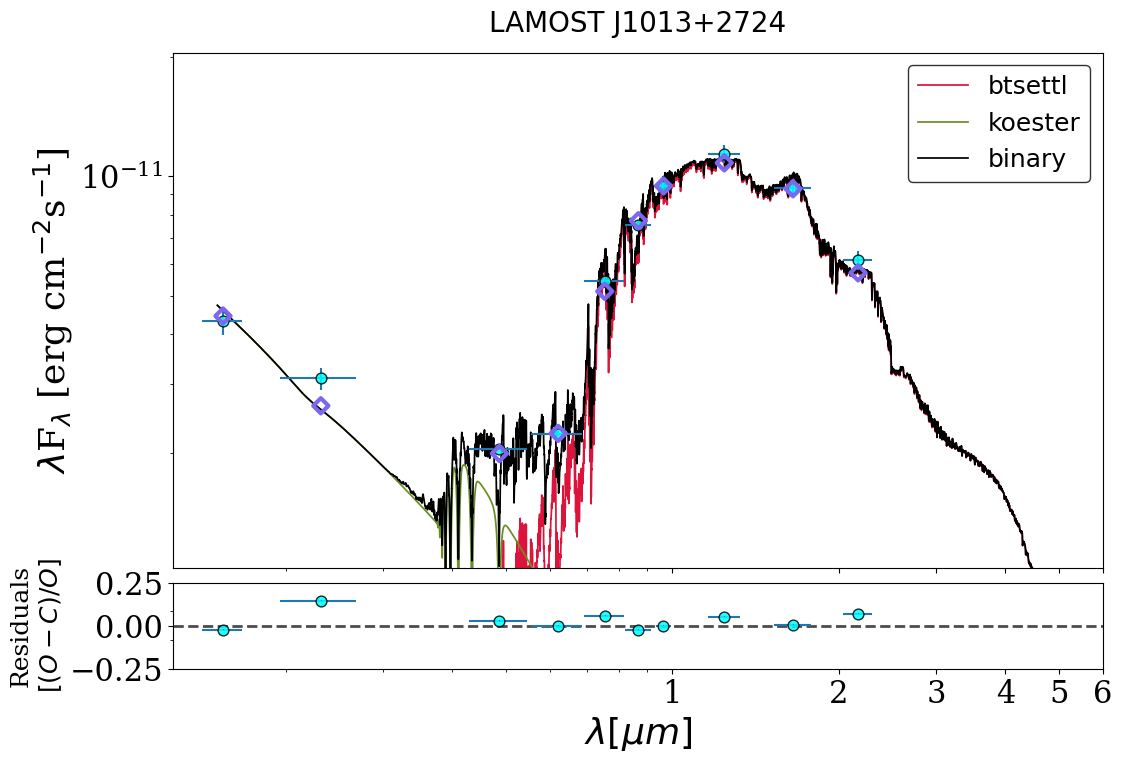

In [10]:
artist = SEDPlotter(in_file, plots_out_folder, pdf=True)
artist.plot_SED_oc(title= 'LAMOST J1013+2724')

Plotting corner.


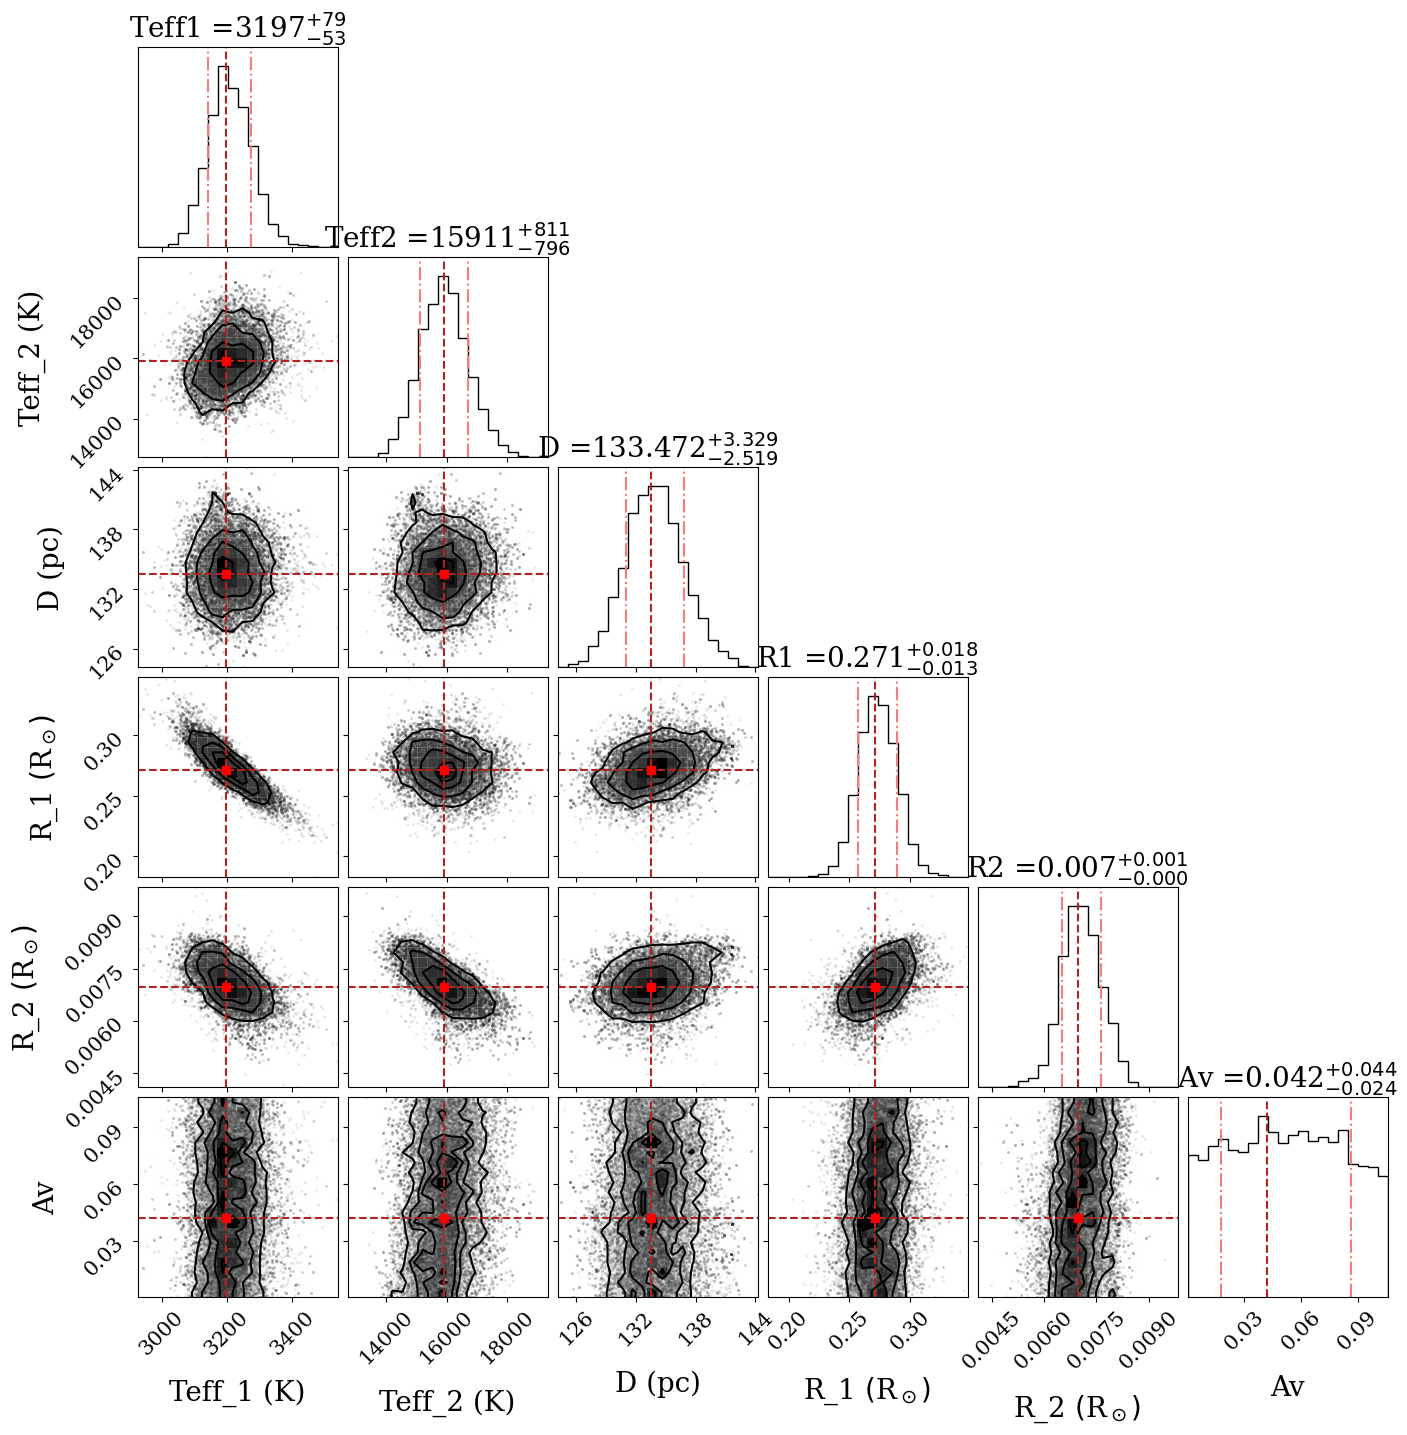

In [11]:
artist.plot_corner(ignor = ['logg1','z1', 'logg2','z2'])